# Assignment 1

Liam Caffrey
21378316

In [79]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report, ConfusionMatrixDisplay

In [80]:
#has 3 inputs --- easier dataset linearly seperable
blobs = pd.read_csv("blobs600.csv")
x_blobs = blobs.iloc[:, :-1]
y_blobs = blobs.iloc[:, -1]
print("blobs inputs length: " ,len(x_blobs))
print("blobs outputs length: " ,len(y_blobs))

#has 2 inputs 
circles = pd.read_csv("circles500.csv")
x_circles = circles.iloc[:, :-1]
y_circles = circles.iloc[:, -1]
print("circles inputs length: " , len(x_circles))
print("circles outputs length: " ,len(y_circles))

blobs inputs length:  600
blobs outputs length:  600
circles inputs length:  500
circles outputs length:  500


In [ ]:
#better readablity used in multiple sections
def logReg(z):
    return 1 / ( 1 + (math.e)**(-z) )

def activaitonDer(input):
    log = logReg(input)
    return log * (1 - log)

def lossfunction(y, y_hat):
    return -( (y * math.log(y_hat)) + ((1-y) * math.log(1-y_hat)) )



In [81]:
# train = 70%
# test = 15%
# validaiton = 15%
X_train1, X_temp, y_train1, y_temp = train_test_split(x_blobs, y_blobs, test_size=0.3, random_state=39)
X_val1, X_test1, y_val1, y_test1 = train_test_split(X_temp, y_temp, test_size=0.5, random_state=39)

print("train size: ", len(X_train1))
print("Val size: ", len(X_val1))
print("test size: ", len(X_test1))

train size:  420
Val size:  90
test size:  90


In [82]:
# train = 70%
# test = 15%
# validaiton = 15%
X_train2, X_temp, y_train2, y_temp = train_test_split(x_circles, y_circles, test_size=0.3, random_state=39)
X_val2, X_test2, y_val2, y_test2 = train_test_split(X_temp, y_temp, test_size=0.5, random_state=39)

print("train size: ", len(X_train2))
print("Val size: ", len(X_val2))
print("test size: ", len(X_test2))

train size:  350
Val size:  75
test size:  75


## Task 1

Implement a Nueral Networks based approach to Lgoistic regression

Explination of algorithm
logisitc regression works by taking an input sample summing all features together and returning a percentage. 
logistic regresion passes its weights to the output node summing up all the features and weights, via the dot product and add the bias. this number is the applied to the activation funciton, sigmoid function here and the output value returns a percentage. with each pass of the dataset our data should slowly push closer and closer to the desired output. This percentage is then put through a threshold and either set to 1 or 0 to determine its class.

stochasitic gradient descent was used with the algorithm. this is where instead of updating weights and bias, based on the average difference we instead calculate the difference between the true value for a selected sample, and its predicted output and we update weights in an attemp to push this value closer to its desired outputs

This forumla does not work well on non-linearly seperable data.

In [ ]:

# version 1 calculation of only a single y_hat, (like in slides from lecture) 
def LogRegNN( X, Y):
    #set up for logistic regression
    alpha = 0.05
    max_iters = 100000
    threshold = 0.01
    N = X.shape[0]

    y_output = [] 

    #weights and bias
    #random generation
    weights = [0] * X.shape[1]
    for i,_ in enumerate(weights):
        weights[i] = np.random.uniform(0,0.01)
    #print("weights: ", weights)

    bias=np.random.uniform(0,0.01)

    #stopping criteria
    going = True
    J_running = 0
    J_running_prev=0
    iteration = 0

    while(going):
        chosenIndex = np.random.randint(0,len(X))

        xi = X.iloc[chosenIndex]
        yi = Y.iloc[chosenIndex]

        z = np.dot(weights, xi) + bias
        y_hat = logReg(z)
        
        #J_current is the loss function
        J_current = lossfunction(yi, y_hat)

        #gradient descent ========================================
        deltaW = [0] * X.shape[1]
        deltaB = 0

        #delta loop
        for j,_ in enumerate(weights):
            deltaW[j] = (y_hat - yi) * xi.iloc[j]

        deltaB = y_hat - yi
            
        #actual update loop 
        for j,_ in enumerate(weights):
            weights[j] = weights[j] - (alpha * deltaW[j])

        bias = bias - (alpha * deltaB) 
            
        
        #stopping criterai
        iteration +=1
        if(iteration > max_iters):
            going = False

        J_running += J_current
        
        if (iteration%N == 0):
            if (abs(J_running - J_running_prev) < threshold):
                going = False
            #print(J_running, " for iteration ", iteration)
            J_running_prev = J_running
            J_running = 0;

    print("===================================================================================")
    print(weights)
    print(bias)
    print("===================================================================================")
    
    # finalise output
    # predict values
    #using final wieghgts and bias
    X = np.array(X)

    for row in X:
        z = np.dot(row, weights) + bias
        y_hat = logReg(z)
        #print(y_hat)
        if y_hat < 0.5:
            y_output.append(0)
        else:
            y_output.append(1)
        
    print("iters: " , iteration)
    #print("final chosen index: ",chosenIndex)
    #print("final z: ", z)
    #print("final Y_hat: ", y_hat)
    #print("final y at chosen location: ", Y.iloc[chosenIndex])
    #print("final loss func: ",lossfunction(Y.iloc[chosenIndex], y_hat))
    #print(len(predictedOut))
    #print("circles: ", x_circles.iloc[499])
    #print("function values: " ,function)
    #print(predictedOut)
    
    return y_output #reutrn all the 1s and 0s

x = LogRegNN(x_blobs, y_blobs)

## Task 2

need to actually predict, best to make a class so weights can be saved

In [83]:
class LogRegNNet:
    
    #setup params for model
    def __init__(self,alpha, max_iters, threshold):
        self.alpha = alpha
        self.max_iters = max_iters
        self.threshold = threshold
        self.weights = 0
        self.bias = 0
        
         
    # here we will train on out data
    # outputs will be the weights and bias
    # so that they can be used later for prediction
    def train(self, X, Y):
        #X and Y here are they training data
        N = X.shape[0] # number amount of data (i.e gives every point the chance to be hit in sgd, could theortically hit all datapoints)

        #weights and bias
        #random generation
        weights = [0] * X.shape[1]
        for i,_ in enumerate(weights):
            weights[i] = np.random.uniform(0,0.01)
        
        bias=np.random.uniform(0,0.01)

        #stopping criteria
        going = True
        J_running = 0
        J_running_prev=0
        iteration = 0

        while(going):
            chosenIndex = np.random.randint(0,len(X))

            X = np.array(X)
            Y = np.array(Y)
            xi = X[chosenIndex]
            yi = Y[chosenIndex]
            #xi = X.iloc[chosenIndex]
            #yi = Y.iloc[chosenIndex]

            z = np.dot(weights, xi) + bias
            y_hat = logReg(z)
        
            #J_current is the loss function
            J_current = lossfunction(yi, y_hat)

            #gradient descent ========================================
            deltaW = [0] * X.shape[1]
            deltaB = 0

            #delta loop
            for j,_ in enumerate(weights):
                deltaW[j] = (y_hat - yi) * xi[j]

            deltaB = y_hat - yi
            
                #actual update loop 
            for j,_ in enumerate(weights):
                weights[j] = weights[j] - (self.alpha * deltaW[j])

            bias = bias - (self.alpha * deltaB) 
            
        
                #stopping criterai
            iteration +=1
            if(iteration > self.max_iters):
                going = False

            J_running += J_current
        
            if (iteration%N == 0):
                if (abs(J_running - J_running_prev) < self.threshold):
                    going = False
                    print("iterations total: " ,iteration)
                #print(J_running, " for iteration ", iteration)
                J_running_prev = J_running
                J_running = 0;

            self.weights = weights
            self.bias = bias
        
        return weights, bias

        #here we precit a new set of inputs using the weights and biases from training
    def predict(self, X):
        #x validaiton and x test

        y_output = [] 

        X = np.array(X)
        for row in X:
            z = np.dot(row, self.weights) + self.bias
            y_hat = logReg(z)
            #print(y_hat)
            if y_hat < 0.5:
                y_output.append(0)
            else:
                y_output.append(1)

        return y_output   

### training and testing - blobs

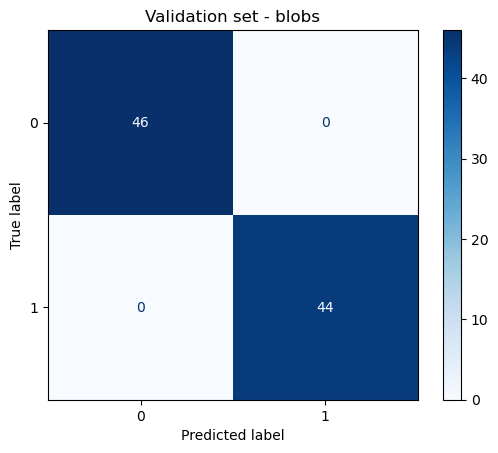


-------------------------------------numerical Scores----------------------------------------------

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        46
           1       1.00      1.00      1.00        44

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



In [85]:
model = LogRegNNet(0.05,10000,0.01)
model.train(X_train1, y_train1)
predictions1 = model.predict(X_val1)

accuracy = accuracy_score(y_val1, predictions1)
cm = confusion_matrix(y_val1, predictions1)
cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
cm.plot(cmap="Blues")
plt.title("Validation set - blobs")
plt.show()
print("")
print("-------------------------------------numerical Scores----------------------------------------------")
print("")
print(f'Accuracy: {accuracy}')
print( classification_report(y_val1, predictions1, target_names=["0", "1"]))

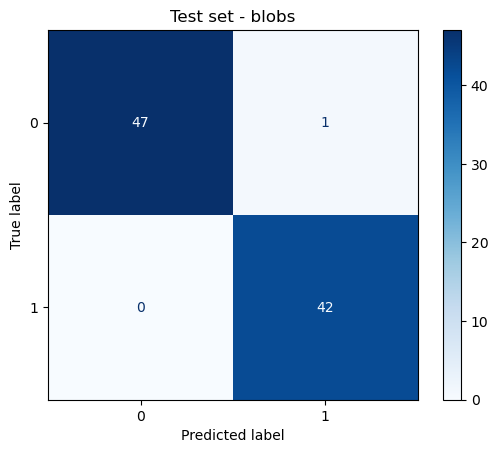


-------------------------------------numerical Scores----------------------------------------------

Accuracy: 0.9888888888888889
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        48
           1       0.98      1.00      0.99        42

    accuracy                           0.99        90
   macro avg       0.99      0.99      0.99        90
weighted avg       0.99      0.99      0.99        90



In [86]:
predictions1 = model.predict(X_test1)

accuracy = accuracy_score(y_test1, predictions1)
cm = confusion_matrix(y_test1, predictions1)
cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
cm.plot(cmap="Blues")
plt.title("Test set - blobs")
plt.show()
print("")
print("-------------------------------------numerical Scores----------------------------------------------")
print("")
print(f'Accuracy: {accuracy}')
print( classification_report(y_test1, predictions1, target_names=["0", "1"]))

### Grpahing test Blobs predictions

In [88]:
print(f"The dimensions of the dataset are: {np.shape(X_test1)}")

The dimensions of the dataset are: (90, 3)


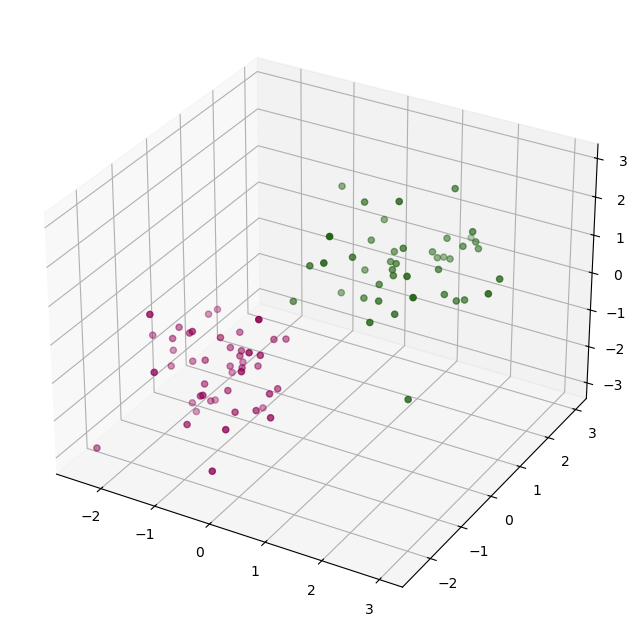

In [89]:
# code form "load-small-datasets"
X_test1 = X_test1.values
fig = plt.figure(figsize=(8, 8)) 
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_test1[:,0], X_test1[:,1], X_test1[:,2], c=predictions1, cmap="PiYG") 

plt.show()
plt.close(fig)

### training and testing - circles

iterations total:  71400


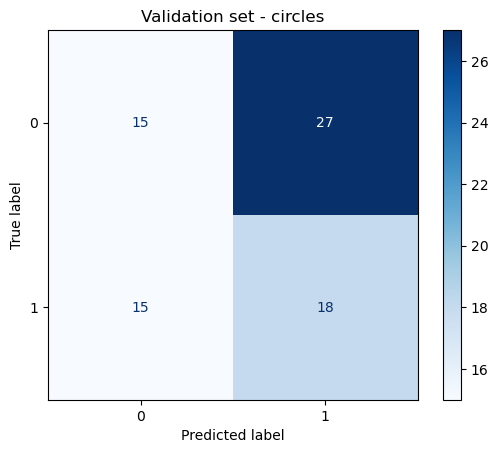


-------------------------------------numerical Scores----------------------------------------------

Accuracy: 0.44
              precision    recall  f1-score   support

           0       0.50      0.36      0.42        42
           1       0.40      0.55      0.46        33

    accuracy                           0.44        75
   macro avg       0.45      0.45      0.44        75
weighted avg       0.46      0.44      0.44        75



In [95]:
model = LogRegNNet(0.05,100000,0.01)
model.train(X_train2, y_train2)
predictions2 = model.predict(X_val2)

accuracy = accuracy_score(y_val2, predictions2)
cm = confusion_matrix(y_val2, predictions2)
cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
cm.plot(cmap="Blues")
plt.title("Validation set - circles")
plt.show()
print("")
print("-------------------------------------numerical Scores----------------------------------------------")
print("")
print(f'Accuracy: {accuracy}')
print( classification_report(y_val2, predictions2, target_names=["0", "1"]))

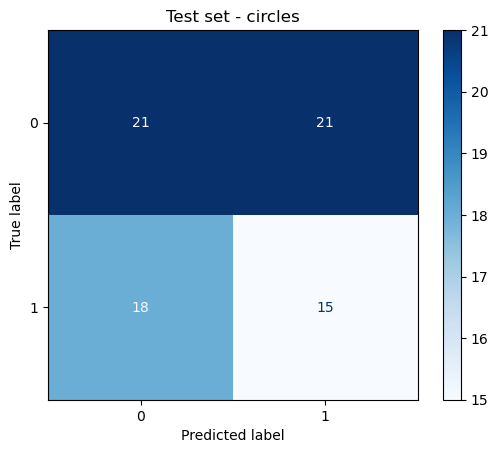


-------------------------------------numerical Scores----------------------------------------------

Accuracy: 0.48
              precision    recall  f1-score   support

           0       0.54      0.50      0.52        42
           1       0.42      0.45      0.43        33

    accuracy                           0.48        75
   macro avg       0.48      0.48      0.48        75
weighted avg       0.48      0.48      0.48        75



In [99]:
predictions2 = model.predict(X_test2)

accuracy = accuracy_score(y_test2, predictions2)
cm = confusion_matrix(y_test2, predictions2)
cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
cm.plot(cmap="Blues")
plt.title("Test set - circles")
plt.show()
print("")
print("-------------------------------------numerical Scores----------------------------------------------")
print("")
print(f'Accuracy: {accuracy}')
print( classification_report(y_test2, predictions2, target_names=["0", "1"]))

### Grpahing test circles predictions

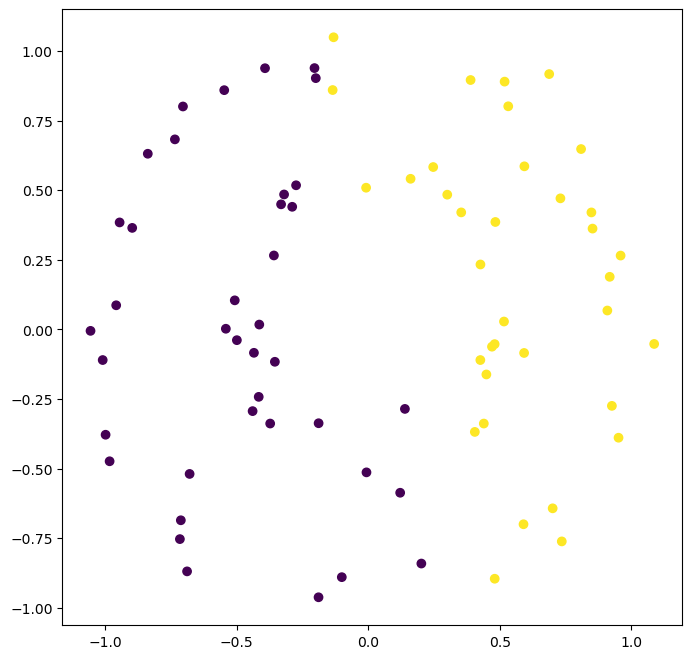

In [102]:
fig, ax = plt.subplots(figsize=(8, 8)) 
ax.scatter(X_test2[:,0], X_test2[:,1], c=predictions2) 

plt.show()
plt.close(fig)

### results

Here we can see that the blobs dataset is capable of achieving good scores using logistic regression as it is linerly seperable.
on the other hand, using logisitc regression the circles dataset isnt able to score well as it is not linearly seperaeble.

we can see this in how for the blobs dataset two clear groups exist within the plot shown.
On the otherhand the two groups predicted in the circles dataset changes each time the funciton is called.



## Task 3 - implement and test a shallow neural network


Explinaiton of model;
this functions much like the logistic regression model, however instead of immediately passing the scores to the output node straight away we use nuerons.

firstly, as if we are passing our outputs to nuerons we calculate the dot product of the current nuerons weights, our features and the nuerons bias.
this is done for every nueron in the layer.

Once this is done we pass our nuerons outputs (one for every sample) to the output layer. The matrix passed in is (number of samples*number of nuerons). with these we multiply each input with the corresponding weight (the weight between the nueron and the output), the are summed up fo revery sample and the bias is added.

once this is done we calculate how far off we are.
we then use this difference to go back through the network backwards to get how much we should update/ change every weight by. one we have the updates for all weights, we simply go over the nextwork once more to update all the weights and biases. 

since we are using stochasitc gradient descent we only use a single sample to get the difference

once this is done we go back over all values and predict them.

the loss curve is done by taking the average loss over the N (number of batch) iterations

the batch number is the number of samples, i.e. it gives SGD the chance to theoritcally use all samples once, unlikely but possible

In [ ]:
class NetNsingle:
    def __init__(self,alpha, max_iters, threshold, layer1):
        self.alpha = alpha
        self.max_iters = max_iters
        self.threshold = threshold
        self.layer1 = layer1

        #hidden layer weights and biases
        self.weightsHL = []
        self.biasHL = []
        
        self.weightsOL = []
        self.biasOL = 0

        self.losshistory = []
        self.iterationhistory = []

    def train(self, X, Y):
        N = X.shape[0]

        # per nueron we have a set of weights
        # each weight corresponds to a feature, 
        weightsHL = [[np.random.uniform(0,0.001) for _ in range(self.layer1)] for _ in range(X.shape[1])]
        weightsHL = np.array(weightsHL)

        #gives me two biases for our example one per nueron
        biasHL = [np.random.uniform(0,0.001) for _ in range(self.layer1)]
        biasHL = np.array(biasHL)
      
        # the nueron outputs are features so need 2 weights one per nueron
        weightsOL = [np.random.uniform(0,0.001) for _ in range(self.layer1)]
        weightsOL = np.array(weightsOL)

        #single bias for single output node
        biasOL=np.random.uniform(0,0.001)

        #stopping criteria
        going = True
        J_running = 0
        J_running_prev=0
        iteration = 0
        losshistory = []
        iterationhistory = []

        # actual process =========================================

        while(going):
            # CHoose random sample
            chosenIndex = np.random.randint(0,len(X))

            X = np.array(X)
            Y = np.array(Y)
            xi = X[chosenIndex]
            yi = Y[chosenIndex]
            #xi = X.iloc[chosenIndex]
            #yi = Y.iloc[chosenIndex]
            
            #xi = X.iloc[chosenIndex]
            #xi = np.array(xi)
            #yi = Y.iloc[chosenIndex]

            # forward pass
            z1 = np.dot(xi, weightsHL) + biasHL
            a1 = logReg(z1)
            
            z2 = np.dot(a1, weightsOL)
            a2 = logReg(z2)

            J_current = lossfunction(yi, a2)
            #graident descent

            #error for layer 2 output layer
            dz2 = a2 - yi
            #error for layer 1
            dz1 = dz2 * weightsOL * activaitonDer(z1)
        
            # initialise
            deltaWOL = [0] * X.shape[1]
            deltaWOL = np.array(deltaWOL)
            deltaBOL = 0
        
            #calculate deltas
            #output layer
            deltaWOL = a1 * dz2
            deltaBOL = dz2
            
            #hidden layer
            deltaWHL = xi[:, None] * dz1[None, :] 
            deltaBHL = dz1

            #apply updates
            #output layer
            weightsOL = weightsOL - (self.alpha * deltaWOL)
            biasOL = biasOL - (self.alpha * deltaBOL)

            weightsHL = weightsHL - (self.alpha * deltaWHL)
            biasHL = biasHL - (self.alpha * deltaBHL)
        
            iteration +=1
            if(iteration > self.max_iters):
                going = False

            J_running += J_current

            if (iteration%N == 0):
                if (abs(J_running - J_running_prev) < self.threshold):
                    going = False
                #print(J_running, " for iteration ", iteration)
                avg_loss = J_running / N
                losshistory.append(avg_loss)
                iterationhistory.append(iteration)
                J_running_prev = J_running
                J_running = 0;

            

        self.weightsHL = weightsHL
        self.biasHL = biasHL        
        self.weightsOL = weightsOL
        self.biasOL = biasOL
        self.losshistory = losshistory
        self.iterationhistory = iterationhistory

        #print(z1)
        print("iterations total: " ,iteration)
        print("")
        return weightsHL, biasHL, weightsOL, biasOL

    def predict(self, X):

        y_output = [] 
        X = np.array(X)

        z1 = np.dot(X, self.weightsHL) + self.biasHL
        a1 = logReg(z1)

        z2 = np.dot(a1, self.weightsOL) + self.biasOL
        a2 = logReg(z2)

        for x in a2:
            if x < 0.5:
                y_output.append(0)
            else:
                y_output.append(1)

        return y_output

    def lossHiss(self):

        plt.plot(self.iterationhistory,self.losshistory)
        plt.xlabel("Iterations")
        plt.ylabel("Average Loss")
        plt.title("Average loss history curve")
        plt.show()
        

### training and testing - blobs

iterations total:  28140



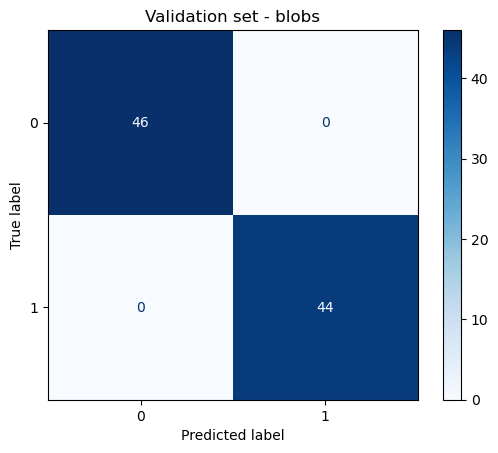


-------------------------------------numerical Scores----------------------------------------------

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        46
           1       1.00      1.00      1.00        44

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



In [103]:
model = NetNsingle(0.01,100000,0.01,15)
model.train(X_train1, y_train1)
predictions3 = model.predict(X_val1)

accuracy = accuracy_score(y_val1, predictions3)
cm = confusion_matrix(y_val1, predictions3)
cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
cm.plot(cmap="Blues")
plt.title("Validation set - blobs")
plt.show()
print("")
print("-------------------------------------numerical Scores----------------------------------------------")
print("")
print(f'Accuracy: {accuracy}')
print( classification_report(y_val1, predictions3, target_names=["0", "1"]))


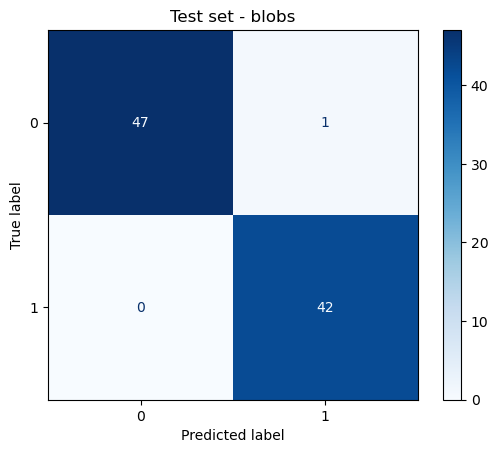


-------------------------------------numerical Scores----------------------------------------------

Accuracy: 0.9888888888888889
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        48
           1       0.98      1.00      0.99        42

    accuracy                           0.99        90
   macro avg       0.99      0.99      0.99        90
weighted avg       0.99      0.99      0.99        90



In [104]:
predictions4 = model.predict(X_test1)

accuracy = accuracy_score(y_test1, predictions4)
cm = confusion_matrix(y_test1, predictions4)
cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
cm.plot(cmap="Blues")
plt.title("Test set - blobs")
plt.show()
print("")
print("-------------------------------------numerical Scores----------------------------------------------")
print("")
print(f'Accuracy: {accuracy}')
print( classification_report(y_test1, predictions4, target_names=["0", "1"]))

### training and testing - circles

iterations total:  497350



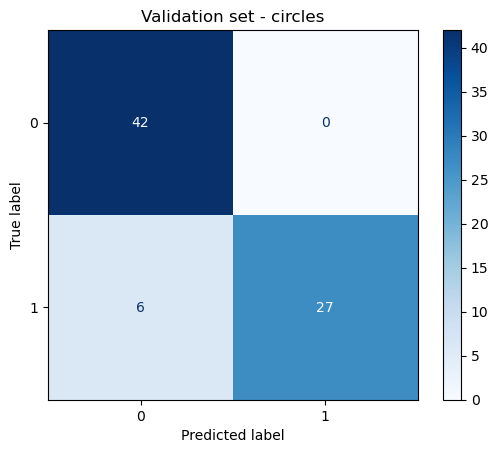


-------------------------------------numerical Scores----------------------------------------------

Accuracy: 0.92
              precision    recall  f1-score   support

           0       0.88      1.00      0.93        42
           1       1.00      0.82      0.90        33

    accuracy                           0.92        75
   macro avg       0.94      0.91      0.92        75
weighted avg       0.93      0.92      0.92        75



In [105]:
model = NetNsingle(0.1,500000,0.001,100)
model.train(X_train2, y_train2)
predictions3 = model.predict(X_val2)

accuracy = accuracy_score(y_val2, predictions3)
cm = confusion_matrix(y_val2, predictions3)
cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
cm.plot(cmap="Blues")
plt.title("Validation set - circles")
plt.show()
print("")
print("-------------------------------------numerical Scores----------------------------------------------")
print("")
print(f'Accuracy: {accuracy}')
print( classification_report(y_val2, predictions3, target_names=["0", "1"]))

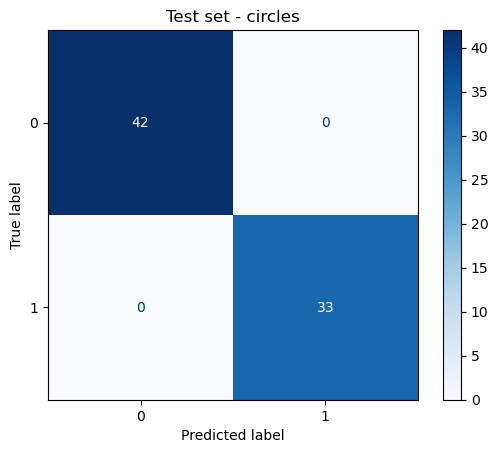


-------------------------------------numerical Scores----------------------------------------------

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      1.00      1.00        33

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



In [106]:
predictions4 = model.predict(X_test2)

accuracy = accuracy_score(y_test2, predictions4)
cm = confusion_matrix(y_test2, predictions4)
cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
cm.plot(cmap="Blues")
plt.title("Test set - circles")
plt.show()
print("")
print("-------------------------------------numerical Scores----------------------------------------------")
print("")
print(f'Accuracy: {accuracy}')
print( classification_report(y_test2, predictions4, target_names=["0", "1"]))

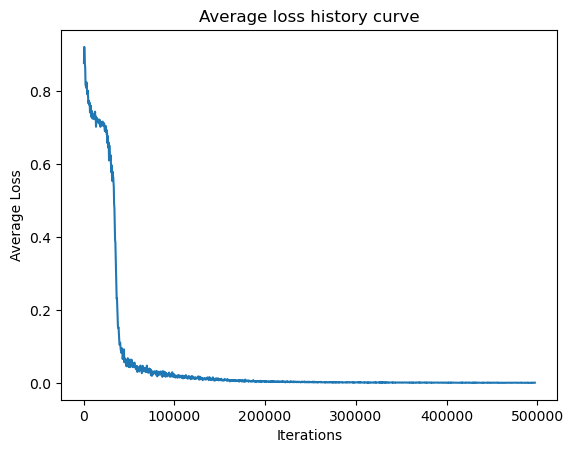

In [107]:
model.lossHiss()

### results

For the coded nueral netowrk with a single layer we can see much better outcomes with the given sets of data.
the blobs data set was able to be trained and was able to achieve good scores on training and validaiton almost immediately.

On the other hand the circles dataset too far more training. Surpirzingly the model would predict all 1s or 0s quite often with a very low alpha score for the circle dataset, however with a higher alpha the model is able to train with much larger steps and was able to achieve consistanly good scores in the validation set. The model was also able to achieve better scores in the final training set.

Its clear that the NN model is far superior to the simple logestic regression model as its scores on the non-linearly seperable dataset easily climb above the logistic regression model.

Changing the number of nodes also makes the model far more stable. Due to SGD the model can at times predict only 1s or 0s if the number of nodes is low.
however as the number of nodes increases the likelyhood of this occuring decreases, for the first dataset this problem seemed to be resolved with very few nodes (10-15), however for the second dataset much more nodes wehere needed to successfully train the model

judging by the loss curve its possible the model will overfit, but it does preform well on the unseen data

## Task 4 - EMNIST DATASET

### read in EMNIST

In [108]:
#code from "load-EMNIST-letters"
data = np.load("emnist_letters_85800.npz")

x_data = data["x"]
y_data = data["y"]

In [109]:
# Extract just two classes from the dataset

# PUT YOUR OWN CLASS NUMBERS HERE: remember that A=1, z=26.
c1 = 6   # f
c2 = 14  # n

mask = (y_data == c1) | (y_data == c2)

x_binary = x_data[mask]
y_binary = y_data[mask]

# Now change labels to 0 and 1
y_binary = (y_binary == c2).astype(int)

In [110]:

def plot_grid(x, y, n):
    plt.figure(figsize=(12, 10))
    
    for i in range(48):
        idx = n + i
        
        plt.subplot(6, 8, i + 1)
        plt.imshow(x[idx].squeeze(), cmap="gray")
        plt.title(int(y[idx]))
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

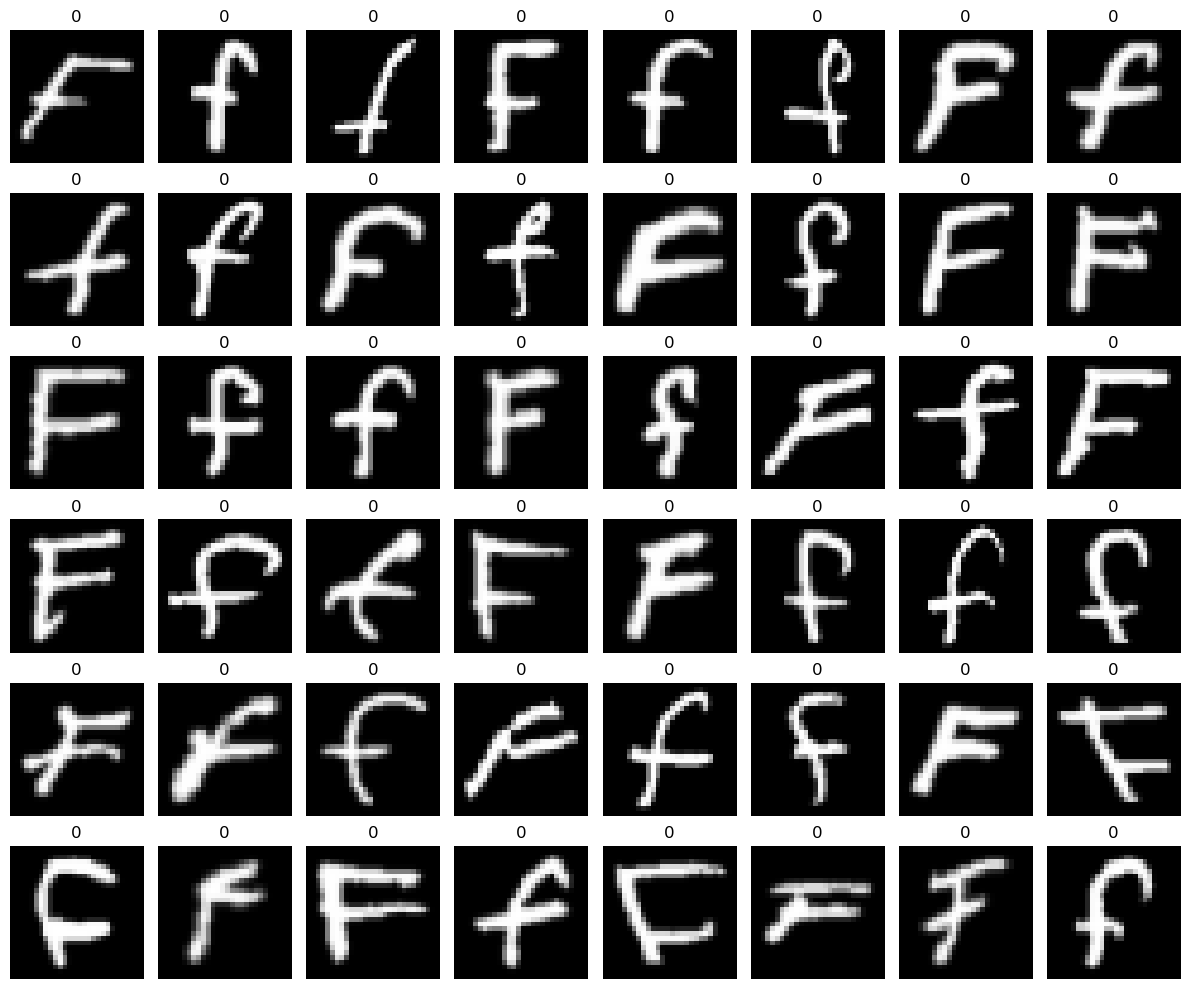

In [111]:
plot_grid(x_binary, y_binary, n=0)

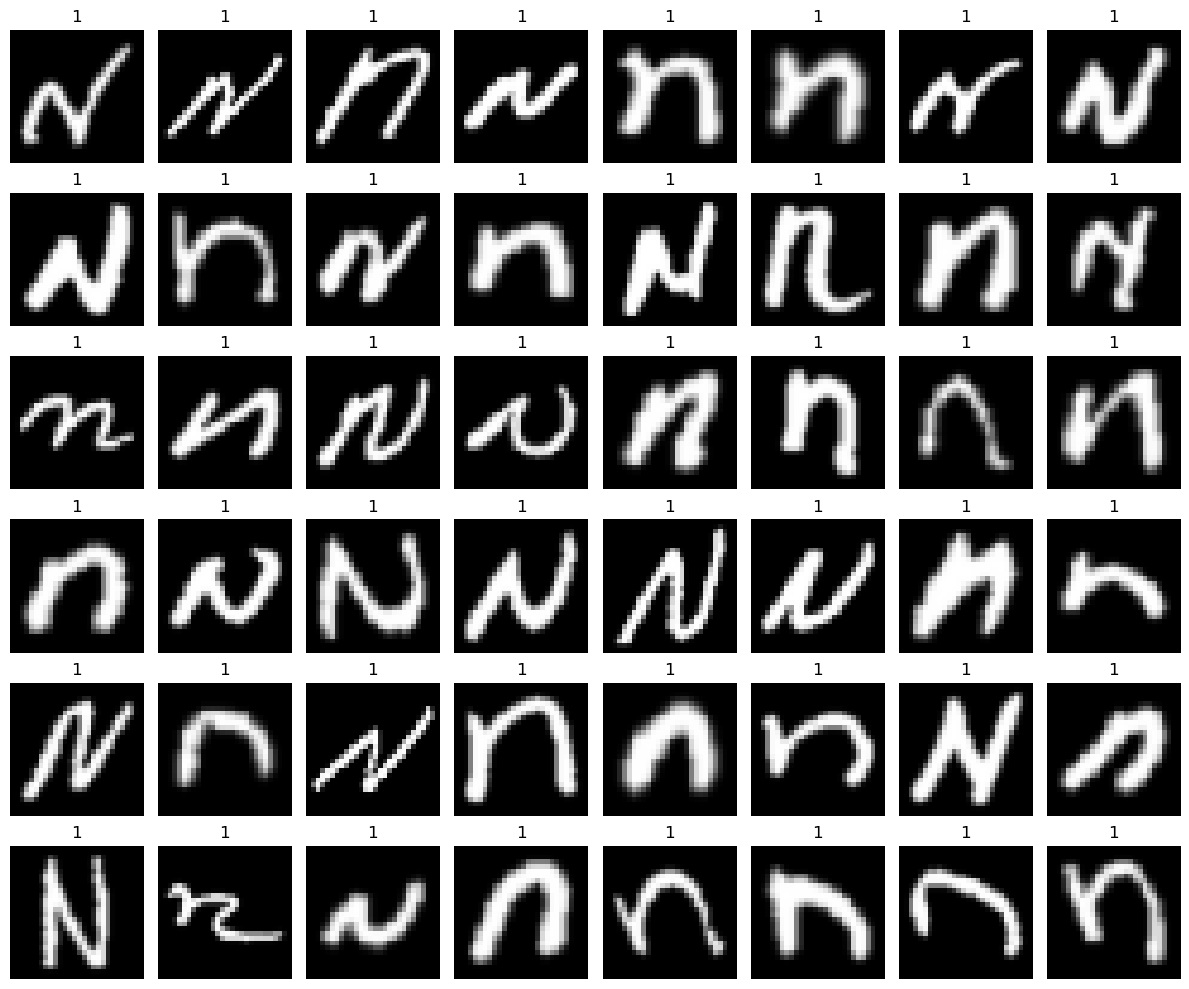

In [112]:
plot_grid(x_binary, y_binary, n=3300)

### model EMNIST

In [113]:

# f is 0
# n is 1
# train = 70%
# test = 15%
# validaiton = 15%

x_flat = x_binary.reshape(x_binary.shape[0],-1)

X_train3, X_temp, y_train3, y_temp = train_test_split(x_flat, y_binary, test_size=0.3, random_state=39)
X_val3, X_test3, y_val3, y_test3 = train_test_split(X_temp, y_temp, test_size=0.5, random_state=39)

print("train size: ", len(X_train3))
print("tain shape: ", X_train3.shape)
print("Val size: ", len(X_val3))
print("Val shape: ", X_val3.shape)
print("test size: ", len(X_test3))
print("test shape: ", X_test3.shape)

train size:  4620
tain shape:  (4620, 784)
Val size:  990
Val shape:  (990, 784)
test size:  990
test shape:  (990, 784)


iterations total:  10001



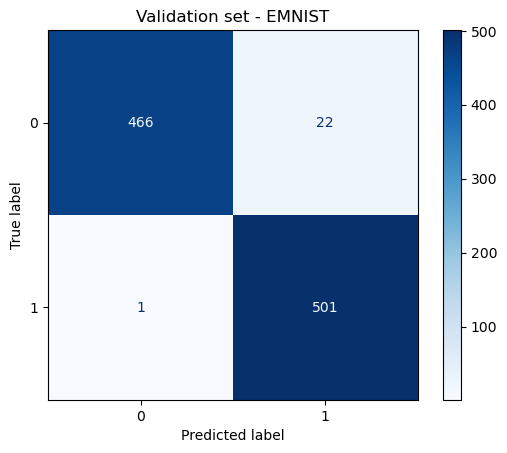


-------------------------------------numerical Scores----------------------------------------------

Accuracy: 0.9767676767676767
              precision    recall  f1-score   support

           0       1.00      0.95      0.98       488
           1       0.96      1.00      0.98       502

    accuracy                           0.98       990
   macro avg       0.98      0.98      0.98       990
weighted avg       0.98      0.98      0.98       990



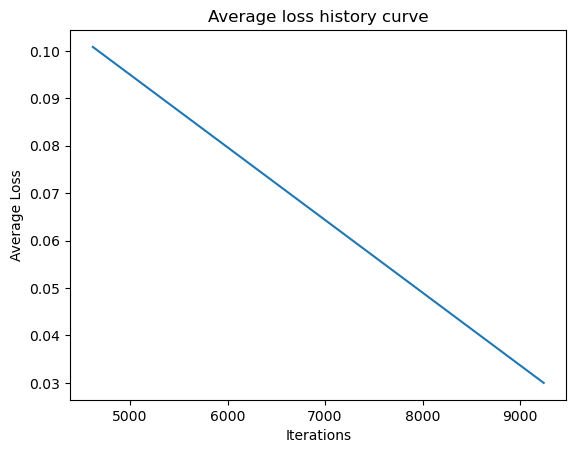

In [114]:
model = NetNsingle(0.1,10000,0.01,100)
model.train(X_train3, y_train3)
predictionsEM = model.predict(X_val3)

accuracy = accuracy_score(y_val3, predictionsEM)
cm = confusion_matrix(y_val3, predictionsEM)
cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
cm.plot(cmap="Blues")
plt.title("Validation set - EMNIST")
plt.show()
print("")
print("-------------------------------------numerical Scores----------------------------------------------")
print("")
print(f'Accuracy: {accuracy}')
print( classification_report(y_val3, predictionsEM, target_names=["0", "1"]))

model.lossHiss()

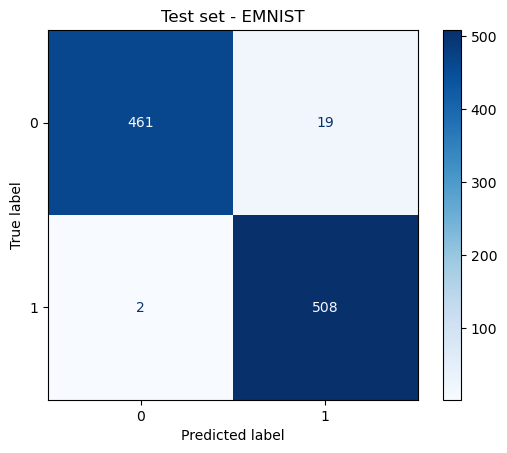


-------------------------------------numerical Scores----------------------------------------------

Accuracy: 0.9787878787878788
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       480
           1       0.96      1.00      0.98       510

    accuracy                           0.98       990
   macro avg       0.98      0.98      0.98       990
weighted avg       0.98      0.98      0.98       990



In [116]:
predictionsEMtest = model.predict(X_test3)

accuracy = accuracy_score(y_test3, predictionsEMtest)
cm = confusion_matrix(y_test3, predictionsEMtest)
cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
cm.plot(cmap="Blues")
plt.title("Test set - EMNIST")
plt.show()
print("")
print("-------------------------------------numerical Scores----------------------------------------------")
print("")
print(f'Accuracy: {accuracy}')
print( classification_report(y_test3, predictionsEMtest, target_names=["0", "1"]))

### Results

(0.01,10000,0.01,100) -- gave very good results 99%
(0.1,10000,0.01,10) -- model guesses all 1s, or 0s

Going off of the letters my designation of F and N

a low number of nodes breaks the algorithm and will just predict 1s or 0s
a higher number of nodes in the hidden layer makes the algorithm more stable and consistant.

surpizingly the results for this prediction consistantly came back quite good with 98% accuracy on the validaiton sets and a final 98% on the test set.
On the discussion board it was suggested that there could be a set of pixels used by one of the letters and not by the other, allowing those to to predict the letter. As the bottom right hand corner is less likely to be used by F and quite likely to be used by N, it could be those set of pixels that offer quite a bit of the pridcting power. Not every letter follows this case but this may be a reason for such high accuracy.




## Task 5 - multi layer

In [117]:
class NetNmulti:
    def __init__(self,alpha, max_iters, threshold, layers):
        self.alpha = alpha
        self.max_iters = max_iters
        self.threshold = threshold
        self.layers = layers # ARRAY OF NODES PER LAYER has to include output layer 1 at end

        #hidden layer weights and biases
        self.weightsHL = []
        self.biasHL = []
        
        self.weightsOL = []
        self.biasOL = 0

        self.losshistory = []
        self.iterationhistory = []

    def train(self, X, Y):
        N = X.shape[0]

        # add input to layers so that we can make cleaner for loop
        self.layers = np.concatenate((np.array([X.shape[1]]), self.layers))
        print(self.layers)


        # per nueron we have a set of weights
        # each weight corresponds to a feature, going to a specific nueron
        weights=[]
        bias=[]

        for i in range(len(self.layers) - 1):
            #creates an array of x*y arrays
            weightsTemp = [[np.random.uniform(0,0.001) for _ in range(self.layers[i])] for _ in range(self.layers[i]+1)]
            
            #creates and array of arrays with each on coresponding to the number of nuerons in the previous layer 
            biasTemp = [np.random.uniform(0,0.001) for _ in range(self.layers[i]+1)]
            weights.append(weightsTemp)
            bias.append(biasTemp)
        
        #stopping criteria
        going = True
        J_running = 0
        J_running_prev=0
        iteration = 0
        losshistory = []
        iterationhistory = []

        # actual process =========================================

        while(going):
            # CHoose random sample
            chosenIndex = np.random.randint(0,len(X))

            X = np.array(X)
            Y = np.array(Y)
            xi = X[chosenIndex]
            yi = Y[chosenIndex]

            # forward pass
            # activations array is basically features, until only a single one remains for all samples
            a = [xi]

            # calculate the activaitons for each layer
            for i in range(len(weights)):
                zTemp = np.dot(a[-1], weights[i]) + bias[i]
                aTemp = logReg(zTemp)
                a.append(aTemp)

            #fupadte the J
            J_current = lossfunction(yi, a[-1])

            iteration +=1
            if(iteration > self.max_iters):
                going = False

   
